# Computer Vision Exam #1

Name: Juan Diego Perez Navarro  
Code: T00067699

## Exercise 1 (homogeneous coordinates)

In [1]:
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display
from matplotlib import pyplot as plt

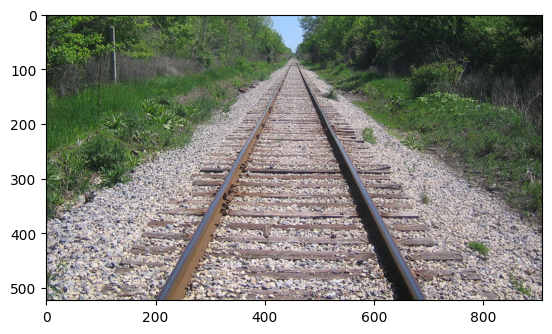

In [2]:
# URL of the image in the GitHub repository
url = "https://raw.githubusercontent.com/fquinterov/computer_vision_course/main/resources/images/train_tracks.png"

# Send a GET request to the URL
response = requests.get(url)

# Open the image from the response content
img = Image.open(BytesIO(response.content))

# Display the image
plt.imshow(img)
plt.show()

- Plot the following points above the image:

\begin{align}
p_1 = \left(
\begin{array}{c}
390\\
200\\
\end{array}
\right)
, \enspace
p_2 = \left(
\begin{array}{c}
280\\
400\\
\end{array}
\right)
,\enspace
p_3 = \left(
\begin{array}{c}
520\\
200\\
\end{array}
\right)
,\enspace \text{and }
p_4 = \left(
\begin{array}{c}
620\\
400\\
\end{array}
\right)
,\enspace
\end{align}

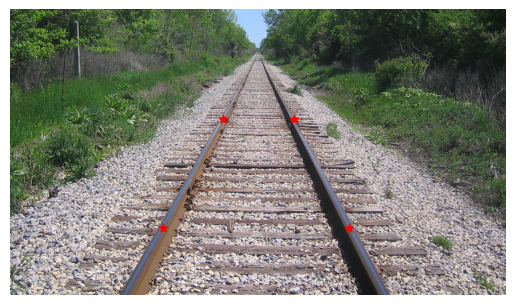

In [4]:
plt.imshow(img)

p1 = (390, 200)
p2 = (280, 400)
p3 = (520, 200)
p4 = (620, 400)

plt.scatter(*p1, color='red', marker='*')
plt.scatter(*p2, color='red', marker='*')
plt.scatter(*p3, color='red', marker='*')
plt.scatter(*p4, color='red', marker='*')

plt.axis('off')
plt.show()

- Calculate the lines that pass through the above points.
- Plot the lines above the image. (Use the function linePoints to plot the lines)

Hint: Use np.cross(p1,p2) to calculate the line that passes through these points.

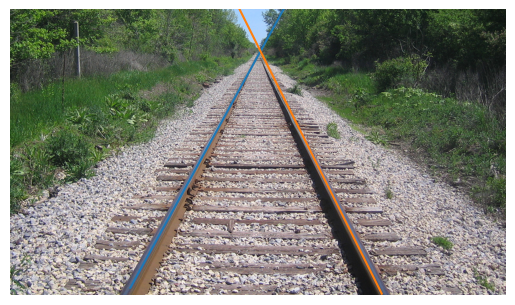

In [16]:
def linePoints(line = [0, 0, 0], ref = [-1.,1.]):
    """given a,b,c for straight line as ax+by+c=0,
    return and plot a pair of points based on ref values
    e.g linePoints(-1,1,2) == [[-1.0, -3.0], [1.0, -1.0]]
    """
    a = line[0]
    b = line[1]
    c = line[2]
    if (a==0 and b==0):
      raise Exception("linePoints: a and b cannot both be zero")
    else:
      points = np.array([[-c/a,p] if b==0 else [p,(-c-a*p)/b] for p in ref])
      plt.plot(points[:, 0], points[:, 1])
      return points


l1 = np.cross([*p1, 1], [*p2, 1])
l2 = np.cross([*p3, 1], [*p4, 1])

plt.imshow(img)

linePoints(l1, ref=[220, 500])
linePoints(l2, ref=[420, 680])

plt.axis('off')
plt.show()

## Exercise 2 (filters)

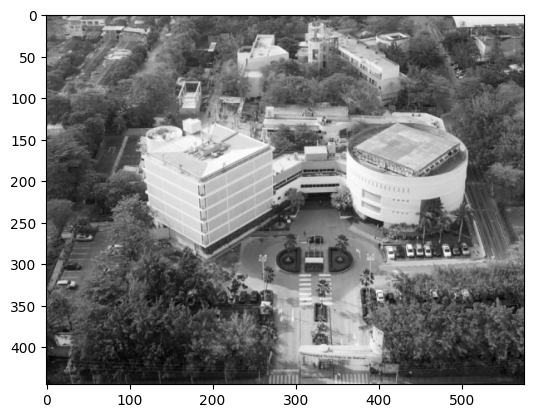

In [9]:
import pandas as pd
import cv2 as cv
from skimage import io
import skimage

# Create a list to store the urls of the images
url = "https://www.utb.edu.co/wp-content/uploads/2024/04/background-unidades-de-apoyo-de-rectoria-1.png"

image = io.imread(url)
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
plt.imshow(image, cmap = 'gray')
plt.show()

- Add a salt and pepper noise to the image and trace the noise image.

Hint: Use the function `skimage.util.random_noise` with mode='s&p'

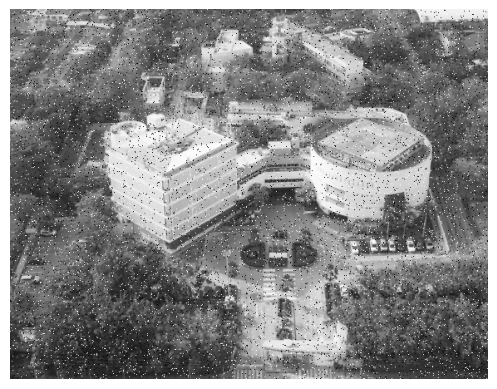

In [11]:
image_sp = skimage.util.random_noise(image, mode='s&p')
plt.imshow(image_sp, cmap='gray')
plt.axis('off')
plt.show()

- Eliminate noise with one of the techniques seen in class (e.g. Gaussian or median filter).

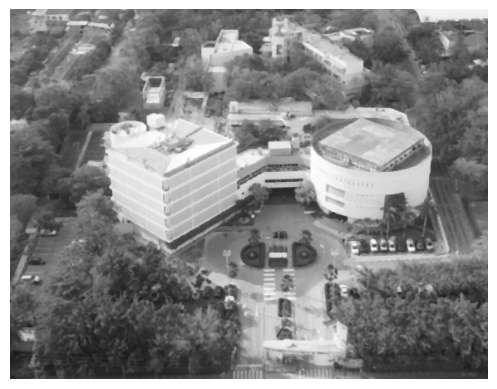

In [19]:
# Usando el filtro de la mediana
image_filtered = skimage.filters.median(image_sp)
plt.imshow(image_filtered, cmap='gray')
plt.axis('off')
plt.show()